In [27]:
import matplotlib.pyplot as plt
import pandas as pd
import pylab as pl
import numpy as np
from sklearn import linear_model

In [5]:
from google.colab import files
uploaded = files.upload()

Saving FuelConsumptionCo2.csv to FuelConsumptionCo2.csv


In [6]:
df = pd.read_csv("FuelConsumptionCo2.csv")

In [7]:
df.head()

,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2014,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,2014,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,2014,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,2014,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,2014,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


In [9]:
df.describe()

,MODELYEAR,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
count,1067.0,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000
mean,2014.0,3.346298,5.794752,13.296532,9.474602,11.580881,26.441425,256.228679
std,0.0,1.415895,1.797447,4.101253,2.794510,3.485595,7.468702,63.372304
min,2014.0,1.000000,3.000000,4.600000,4.900000,4.700000,11.000000,108.000000
25%,2014.0,2.000000,4.000000,10.250000,7.500000,9.000000,21.000000,207.000000
50%,2014.0,3.400000,6.000000,12.600000,8.800000,10.900000,26.000000,251.000000
75%,2014.0,4.300000,8.000000,15.550000,10.850000,13.350000,31.000000,294.000000
max,2014.0,8.400000,12.000000,30.200000,20.500000,25.800000,60.000000,488.000000


In [77]:
# FUELCONSUMPTION_COMB = combined fuel consumption rate of a vehicle, measured in (Liters/100 km)
df = df[['ENGINESIZE','CYLINDERS','FUELCONSUMPTION_COMB','CO2EMISSIONS']]
df.head()

,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_COMB,CO2EMISSIONS
0,2.0,4,8.5,196
1,2.4,4,9.6,221
2,1.5,4,5.9,136
3,3.5,6,11.1,255
4,3.5,6,10.6,244


<function matplotlib.pyplot.show(close=None, block=None)>

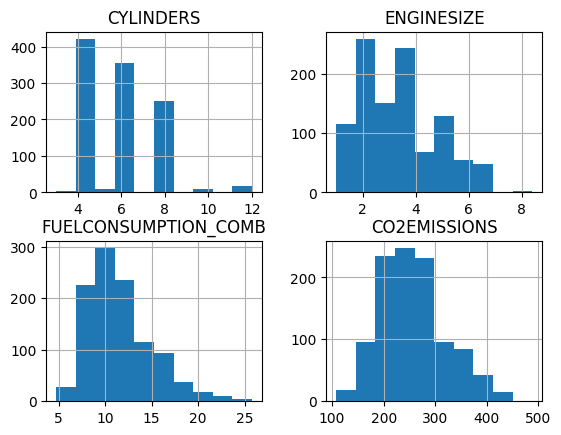

In [57]:
df = df[['CYLINDERS','ENGINESIZE','FUELCONSUMPTION_COMB','CO2EMISSIONS']]
df.hist()
plt.show

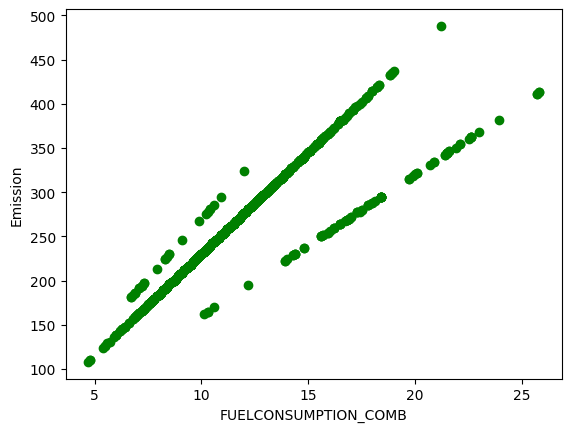

In [17]:
plt.scatter(df.FUELCONSUMPTION_COMB, df.CO2EMISSIONS,  color='green')
plt.xlabel("FUELCONSUMPTION_COMB")
plt.ylabel("Emission")
plt.show()

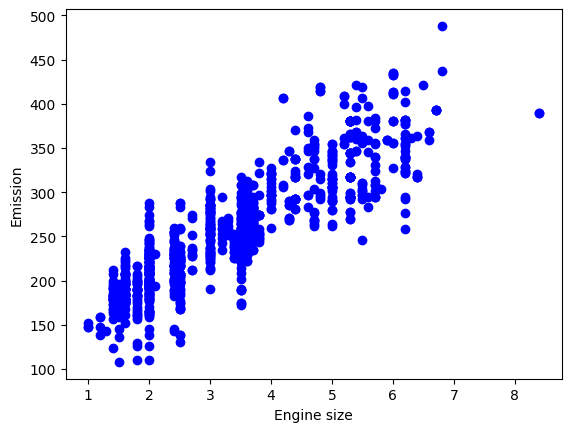

In [18]:
plt.scatter(df.ENGINESIZE, df.CO2EMISSIONS,  color='blue')
plt.xlabel("Engine size")
plt.ylabel("Emission")
plt.show()

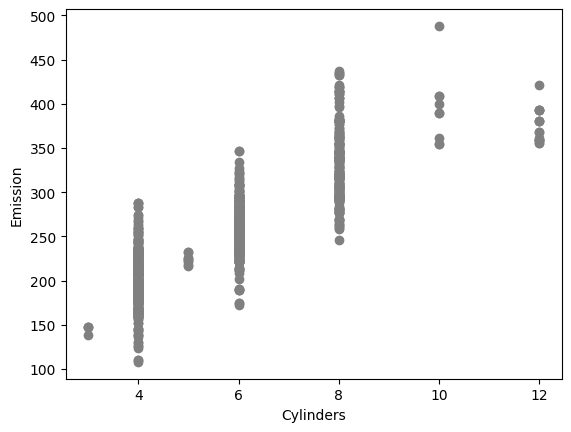

In [25]:
plt.scatter(df.CYLINDERS, df.CO2EMISSIONS,  color='gray')
plt.xlabel("Cylinders")
plt.ylabel("Emission")
plt.show()

In [58]:
X=df.iloc[:,0:3]
Y=df.iloc[:,-1]

In [59]:
X

,CYLINDERS,ENGINESIZE,FUELCONSUMPTION_COMB
0,4,2.0,8.5
1,4,2.4,9.6
2,4,1.5,5.9
3,6,3.5,11.1
4,6,3.5,10.6
...,...,...,...
1062,6,3.0,11.8
1063,6,3.2,11.5
1064,6,3.0,11.8
1065,6,3.2,11.3


In [60]:
Y

,CO2EMISSIONS
0,196
1,221
2,136
3,255
4,244
...,...
1062,271
1063,264
1064,271
1065,260


In [61]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=2)

In [62]:
from sklearn.linear_model import LinearRegression

In [63]:
lr = LinearRegression()

In [64]:
lr.fit(X_train,Y_train)

LinearRegression()

In [65]:
X_test


,CYLINDERS,ENGINESIZE,FUELCONSUMPTION_COMB
455,8,5.3,12.7
954,4,2.5,12.5
738,8,5.5,13.1
913,6,3.0,10.6
702,4,1.5,7.4
...,...,...,...
311,6,3.6,10.2
848,6,3.5,10.9
508,6,3.3,11.2
330,6,3.6,12.0


In [66]:
Y_test

,CO2EMISSIONS
455,292
954,288
738,301
913,286
702,170
...,...
311,235
848,251
508,258
330,276


In [71]:
lr.predict(X_test.iloc[0].values.reshape(1,3))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([304.41959015])

In [72]:
m = lr.coef_

In [73]:
c=  lr.intercept_

In [74]:
m

array([ 7.01508244, 11.63291754,  9.25865957])

In [75]:
c

np.float64(69.05949122332137)

In [76]:
# CO2EMISSIONS  = m1 * CYLINDERS + m2 * ENGINESIZE + m3 * FUELCONSUMPTION_COMB + c
7.01508244*4 + 11.63291754*2.0 +  9.25865957*8.5 + c

np.float64(199.08426240832137)

### Model Evaluation
###Let's evaluate the performance of our updated linear regression model using R-squared and Mean Squared Error. These metrics will help us understand how well the model predicts `CO2EMISSIONS` on unseen data.

In [85]:
Y_pred_lr = lr.predict(X_test)

# evaluation
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

rmse_lr = np.sqrt(mean_squared_error(Y_test, Y_pred_lr))
mae_lr = mean_absolute_error(Y_test, Y_pred_lr)
r2_lr = r2_score(Y_test, Y_pred_lr)

print("Linear Regression Results")
print("RMSE:", rmse_lr)
print("MAE :", mae_lr)
print("R²  :", r2_lr)

Linear Regression Results
RMSE: 22.446870258445756
MAE : 16.132545872637
R²  : 0.89119029063663


 #### R-squared value is approximately 0.8912. This is a very good score! R-squared represents the proportion of the variance in the dependent variable (CO2EMISSIONS) that is predictable from the independent variables (CYLINDERS, ENGINESIZE, FUELCONSUMPTION_COMB). An R-squared of 0.8912 means that approximately 89.12% of the variation in CO2 emissions can be explained by your model's features.